In [1]:
import matplotlib.pyplot as plt
%matplotlib widget
import sys
sys.path.append('/home/dtward/data/csh_data/emlddmm/')
import emlddmm
import numpy as np
from os import makedirs
from os.path import join, basename
from glob import glob
import re


import tifffile 
import torch

use display True


In [2]:
outdir = '/home/dtward/Documents/UCLA/yanglab/yanglab_transformed_swcs_2026_09_16'
makedirs(outdir,exist_ok=True)
registration_output_filename = '/home/dtward/Documents/UCLA/yanglab/yang_outputs_april_2026.npz'

swc_filenames = glob('/home/dtward/Documents/UCLA/yanglab/yanglab_swcs_2026_09_16/*.swc')
swc_filenames.sort()

target_image_filename = '/home/dtward/Documents/UCLA/yanglab/20241017_5xFAD_Etv1_MORF3_MEF119_3_4m_RH_9x_C1.npz'
atlas_name = '/home/dtward/Documents/UCLA/dong/9.3.label.tif'

In [3]:
# pixel size of original data
# NOTE when I load the highres image and downsample it, thecoordinate system was defined to be zero mean 
dI0 = np.array([2.0, 1.8, 1.8]) # for 4x
if '9x' in target_image_filename:
    dI0 = np.array([2.0,0.71,0.71])    

# Part 1
Load the SWCs.

In [4]:
parser = re.compile('[0-9]+-[0-9]+-[0-9]*') # this pattern is required for the parser to work

In [5]:
# I need to load and modify the vertices only
# the edges will stay exactly the same
# all the 
vertices = []
offsets = []
for filename in swc_filenames:
    # get the offset from the filename
    print(filename)
    loc = parser.findall(filename)[0]
    offsets.append( np.array( [float(l) for l in loc.split('-')] ) )

    # open the file and parse the vertices
    vertices_ = []
    with open(filename) as f:
        for line in f:
            line = line.strip()
            if not line: continue # no blank lines
            
            
            if not all([str.isnumeric(x.replace('.','').replace('-','')) for x in line.split(',')]): continue
            
            vertices_.append( [float(q) for q in line.split(',')[2:5]] )
    vertices.append(np.array(vertices_)*0 + offsets[-1]) # HACK, I multiplied the vertices by zero because I suspect this is dummy data
        

/home/dtward/Documents/UCLA/yanglab/yanglab_swcs_2026_09_16/01_xyz-6094-2972-988_scaled.swc
/home/dtward/Documents/UCLA/yanglab/yanglab_swcs_2026_09_16/02_xyz-8001-6860-1315_scaled.swc
/home/dtward/Documents/UCLA/yanglab/yanglab_swcs_2026_09_16/03_xyz-8578-12864-1698_scaled.swc


In [6]:
offsets

[array([6094., 2972.,  988.]),
 array([8001., 6860., 1315.]),
 array([ 8578., 12864.,  1698.])]

In [7]:
# fli the vertices xyz -> slice row cl
vertices = [v[:,::-1] for v in vertices]

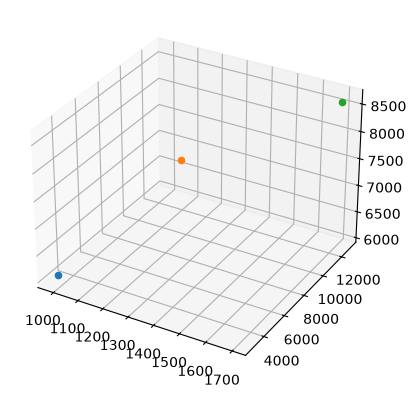

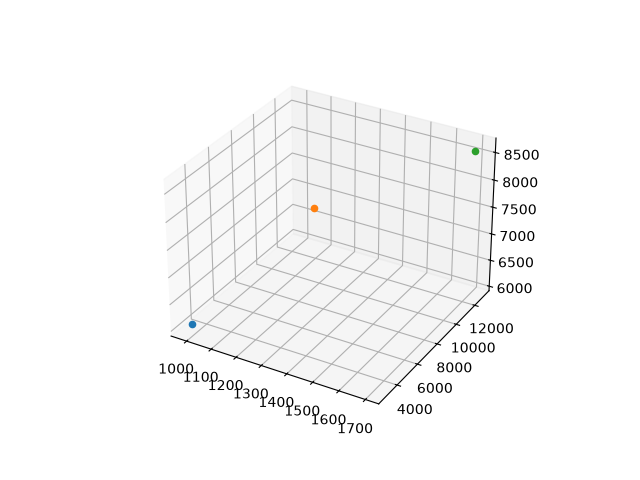

In [8]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
for i in range(len(vertices)):
    ax.scatter(*vertices[i].T)
display(fig)    
    

# Part 2
Load the image and show that they line up.

In [9]:
data = np.load(target_image_filename,allow_pickle=True)
xI = data['xI']
I = data['I']

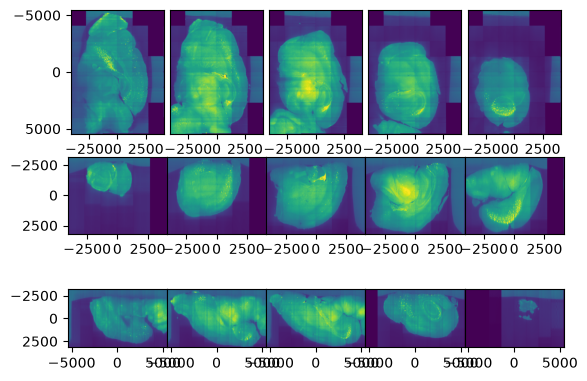

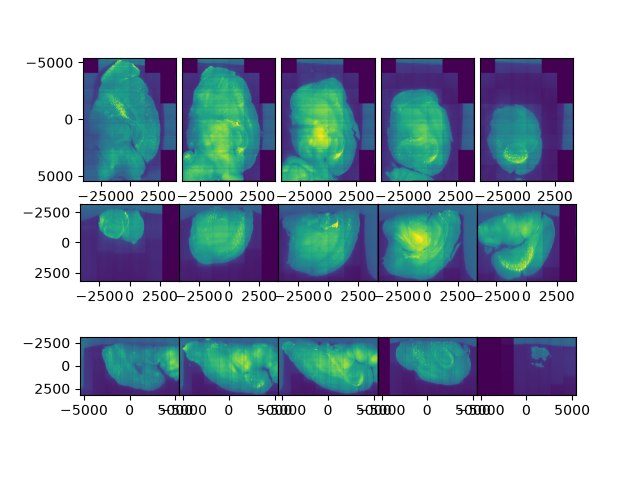

In [10]:
fig,ax = emlddmm.draw(I,xI)
display(fig)

# part 3
convert the swc to the coordinate system I used for registration

In [11]:
dI = np.array( [x[1] - x[0] for x in xI] )
down = dI/dI0
print(down)

[12.5        35.21126761 35.21126761]


In [12]:
# this is not exactly the origin
o = np.array([x[0] for x in xI])
print(o)
# the first coordinate at low res is the average of the first few high res
# this is a weight for the next pixel after the floor of the sownsample factor
# if the decimal point above is small the weight should be small
weight = [ (q - np.floor(q))  for q in down]
nums = [np.arange(np.floor(d)+1) for d in down]

off = []
for i in range(3):
    weights = np.ones_like(nums[i])
    weights[-1] = weight[i]
    weights = weights / np.sum(weights)
    off.append( np.sum(weights*nums[i])/np.sum(weights))   
off = np.array(off)
print(off)
# subtract this number to get the corner at high res, it's about half a low res voxel
o0 = o - off

[-3183.    -5427.595 -4105.575]
[ 5.76  17.108 17.108]


In [13]:
vertices_space = []
for v in vertices:
    vertices_space.append(
        v*dI0 + o0
    )

In [14]:
vertices_space

[array([[-1212.76 , -3334.583,   204.057]]),
 array([[-558.76 , -574.103, 1558.027]]),
 array([[ 207.24 , 3688.737, 1967.697]])]

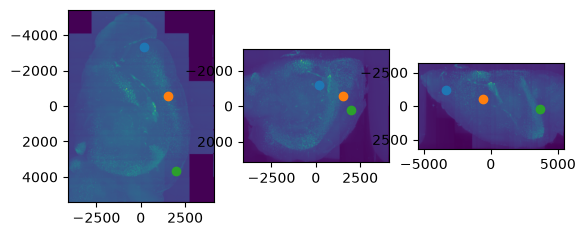

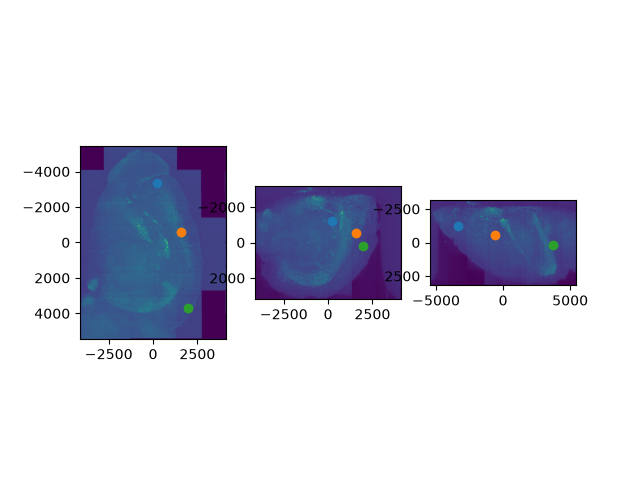

In [15]:
fig,ax = plt.subplots(1,3)
extentI0 = emlddmm.extent_from_x(xI[[1,2]])
ax[0].imshow(I.max((0,1))**0.5,extent=extentI0)
for v in vertices_space:
    ax[0].scatter(*v[:,[2,1]].T) # xy flip
extentI1 = emlddmm.extent_from_x(xI[[0,2]])
ax[1].imshow(I.max((0,2))**0.5,extent=extentI1)
for v in vertices_space:
    ax[1].scatter(*v[:,[2,0]].T) # xy flip

extentI2 = emlddmm.extent_from_x(xI[[0,1]])
ax[2].imshow(I.max((0,3))**0.5,extent=extentI2)
for v in vertices_space:
    ax[2].scatter(*v[:,[1,0]].T) # xy flip

display(fig)

# Part 4 load and apply the transform

In [16]:
tformdata = np.load(registration_output_filename,allow_pickle=True)['arr_0'].item()

In [17]:
tform = emlddmm.compose_sequence(
    [
        emlddmm.Transform(tformdata['A'],'b'),
        emlddmm.Transform(tformdata['v'],'b',domain=tformdata['xv'])
    ],
    [x for x in xI]
)

In [18]:
stacked_points = torch.tensor( np.concatenate(vertices_space,).T)[...,None,None]

In [19]:
transformed_stacked_points = emlddmm.apply_transform_float(xI,tform,stacked_points)[...,0,0]

In [20]:
# unstack them
transformed_points = []
c = 0
for i in range(len(vertices)):
    transformed_points.append(  transformed_stacked_points[:,c:c+vertices[i].shape[0]].numpy().T)
    c = c + vertices[i].shape[0]
    

# Part 5 load the atlas and convert back from space to indices

In [21]:

L = tifffile.imread(atlas_name)

In [22]:
L.shape

(1400, 900, 1140)

In [23]:
xL = np.array( [np.arange(n)*10.0 - (n-1)*10.0/2 for n in L.shape[-3:]]    , dtype=object)

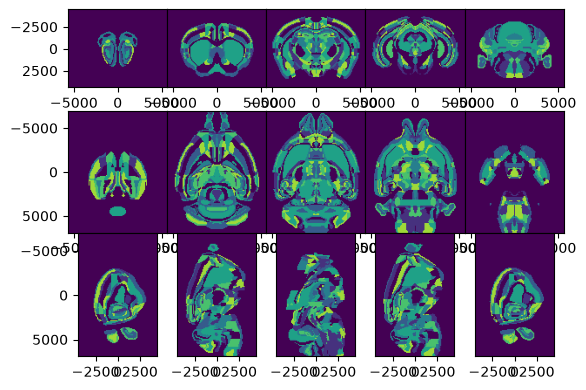

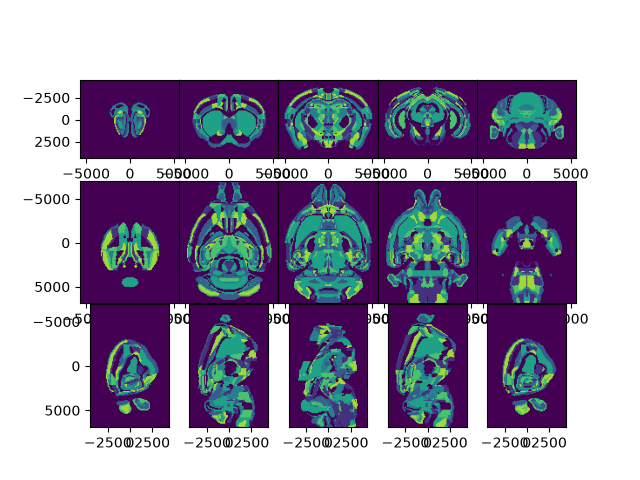

In [24]:
downshow = 10
nmod=7
fig,ax = emlddmm.draw(L[None,::downshow,::downshow,::downshow]%nmod, [x[::downshow] for x in xL],vmin=0,vmax=nmod)
display(fig)


In [25]:
M = (L>0)[None]

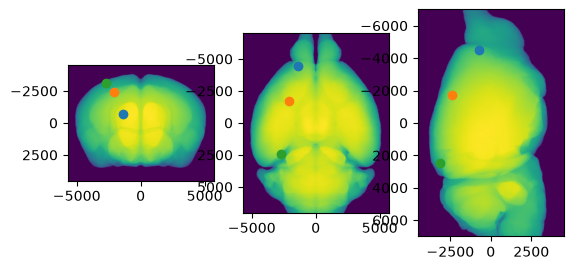

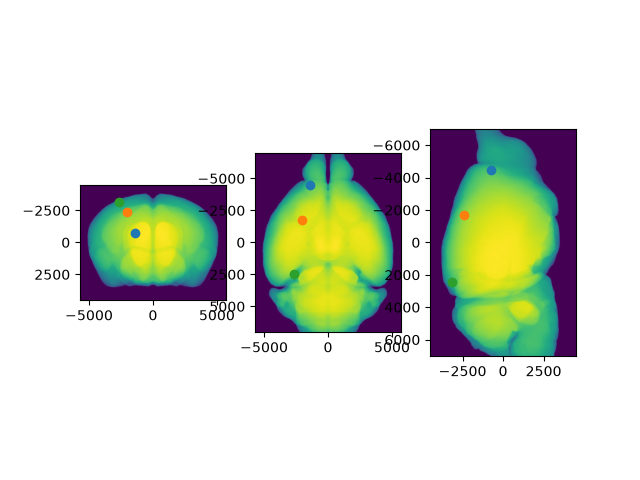

In [26]:
fig,ax = plt.subplots(1,3)
extentL0 = emlddmm.extent_from_x(xL[[1,2]])
ax[0].imshow(M.mean((0,1))**0.5,extent=extentL0)
for v in transformed_points:
    ax[0].scatter(*v[:,[2,1]].T) # xy flip

extentL1 = emlddmm.extent_from_x(xL[[0,2]])
ax[1].imshow(M.mean((0,2))**0.5,extent=extentL1)
for v in transformed_points:
    ax[1].scatter(*v[:,[2,0]].T) # xy flip

extentL2 = emlddmm.extent_from_x(xL[[0,1]])
ax[2].imshow(M.mean((0,3))**0.5,extent=extentL2)
for v in transformed_points:
    ax[2].scatter(*v[:,[1,0]].T) # xy flip

display(fig)

In [27]:
oL = np.array( [x[0] for x in xL])
dL = np.array( [x[1] - x[0] for x in xL])

In [29]:
transformed_points_indices = []
for i in range(len(transformed_stacked_points)):
    transformed_points_indices.append( (transformed_points[i] - oL)/dL )


# Part 6, write out the data

For now I will take the original filename, and replace the data inside with a transformed point.

In [30]:
# I need to load and modify the vertices only
# the edges will stay exactly the same
# all the 
fcount = 0
for filename in swc_filenames:
    # get the offset from the filename
        
    # open the file and parse the vertices
    vertices_ = []
    with open(filename) as f:
        with open(join(outdir,basename(filename).replace('.swc','_transformed.swc')),'wt') as fo:
            for line in f:
                line0 = str(line)
                line = line.strip()
                if not line: 
                    fo.write(line0)
                    continue # no blank lines                
                
                if not all([str.isnumeric(x.replace('.','').replace('-','')) for x in line.split(',')]): 
                    fo.write(line0)
                    continue
                # write the new vertex
                parts = line0.split(',')
                parts[2] = str(transformed_points_indices[fcount][len(vertices_)][2].item())
                parts[3] = str(transformed_points_indices[fcount][len(vertices_)][1].item())
                parts[4] = str(transformed_points_indices[fcount][len(vertices_)][0].item())
                outstr = ','.join(parts)                                
                
                fo.write( outstr )
                vertices_.append( [float(q) for q in line.split(',')[2:5]] )
        
    fcount += 1
        